# **Group H**

# **Student Name: Sunil Bastola, Minh Hieu Doan, Sabrin Luitel, Christian Orca, YIU Hok Yu (Jocelyn)**

# **Student ID: 48659851, 48489115, 48343188, 48304069, 48715638**

# **Research Paper Analysis and Recommendation System**

## **Introduction**

This notebook presents the evaluation and comparison of NLP and LLM techniques built for **Papermind**, the academic research assistant that analyses arXiv papers, extracts metadata, summarises findings, identifies research gaps, and recommends relevant papers from the Cornell arXiv dataset. Since the size of Kaggle Cornell arXiv dataset is huge, only 8000 research papers are used for this assignment.

### **System Overview**

Papermind is designed around a multi-stage pipeline: (1) **Metadata extraction**: parse authors, institutions, and domain labels from raw paper records using rule-based NER and regular expressions, (2) **Domain classification**: assign each paper to a primary arXiv category (e.g. `cs.AI`, `cs.IT`) using a trained text classifier, (3) **Summarisation**: produce a concise summary of a paper's core contribution using both extractive and generative approaches, (4) **Research gap identification**: surface topics and methods that are underrepresented relative to the paper's research domain, (5) **Paper recommendation**: retrieve semantically relevant papers from the corpus using embedding-based similarity.

### **Implemented Techniques**

**Basic NLP techniques:**
- Text preprocessing: lowercasing, punctuation removal, custom stopword filtering
- TF-IDF keyword extraction: identifies high-weight grams per paper using inverse document frequency weighting
- Bag-of-Words (BoW): term frequency representation used as a baseline keyword extractor
- Rule-based NER and metadata extraction: regular expressions for author parsing and institution detection
- Text classification: TF-IDF features fed into Logistic Regression and Naive Bayes classifiers to predict arXiv domain
- Extractive summarisation: TextRank using TF-IDF cosine similarity to score and select representative sentences
- Embedding similarity: sentence level dense embeddings (`all-MiniLM-L6-v2`) indexed with cosine-metric Nearest Neighbours for semantic retrieval
- TF-IDF cosine similarity retrieval: for keyword overlapping within the reseaech paper for recommendation baseline

**Advanced NLP techniques:**
- Retrieval-Augmented Generation (RAG): retrieved paper abstracts are injected as grounded context for the LLM
- LoRA fine-tuning setup: parameter-efficient fine-tuning scaffold using PEFT, demonstrating how the system could be adapted for domain-specific instruction following
- Instruction prompting: structured prompts with explicit role, task, format, and constraint sections to steer generation
- Few-shot prompting: two in-context examples guide the model toward a consistent output style
- Chain-of-Thought (CoT) prompting: step-by-step scratchpad elicits deeper reasoning before the model commits to a final answer
- ReAct prompting: interleaved thought, action, observation steps simulate a reasoning agent that searches and inspects before concluding
- Add privacy, fairness, and ethics aware within the prompt: constraints embedded in prompts so that it helps to prevent hallucination, bias, and fabricated citations
- LLM summarisation and research-gap generation: Gemini 2.5 Flash model of the Gemini API keys is used for both abstractive summarisation and structured gap identification.

The structure of the experiment in this jupyter notebook includes the below:

1. **Load arXiv Metadata:** Dataset loading, column selection, and text preprocessing to prepare the 8,000-paper corpus.
2. **Experiment 1 (Basic vs Basic):** Head-to-head comparison of traditional NLP techniques:
    1. TF-IDF vs Bag-of-Words keyword extraction
    2. Logistic Regression vs Naive Bayes classification
    3. TextRank vs first-N sentence summarisation
    4. Dense embedding vs TF-IDF cosine similarity retrieval
3. **Experiment 2 (Advanced vs Advanced):** Comparison of LLM prompting strategies:
    1. Single-shot vs instruction vs few-shot summarisation
    2. Single-shot vs CoT vs ReAct research-gap identification
    3. LLM without context vs RAG + instruction vs RAG + ReAct recommendation
4. **Experiment 3 (Basic vs Advanced):** Direct comparison between the best traditional technique and its LLM counterpart:
    1. Keyword-based gap identification vs CoT
    2. TF-IDF retrieval vs RAG + ReAct recommendation
    3. TextRank vs instruction prompting summarisation, including an enriched-context variant that injects query domain and TF-IDF keywords into the prompt


In [ ]:
# Import all necessary libraries
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
import dotenv
import os

# Load environment variables from .env file
dotenv.load_dotenv(dotenv_path='.env')
GEMINI_API_KEY = os.environ['GEMINI_API_KEY']
# Set random seed for reproducibility and the maximum number of papers to extract is 8000
RANDOM_STATE = 42
MAX_PAPERS = 8000
DATA_FILE = Path('arxiv-metadata-oai-snapshot.json')

## **Section 1: Load arXiv Metadata**

Loads the Cornell arXiv dataset, which contains metadata for over 2 million research papers spanning computer science, mathematics, physics, and related fields. For this project, a subset of 8,000 papers is used, filtered to computer science (`cs.*`) and machine learning (`stat.ML`) categories to keep the corpus focused and manageable.

Each paper record includes the title, abstract, authors, arXiv categories, and publication metadata. These fields are combined into a `paper_text` column (title + abstract) used throughout the notebook for feature extraction, classification, and retrieval. A `primary_category` column is also derived from the first listed arXiv category, which serves as the class label for the text classification experiments.

The dataset file `arxiv-metadata-oai-snapshot.json` should be placed in this

In [ ]:
def resolve_dataset_path() -> Path:
    if DATA_FILE.exists():
        return DATA_FILE

    try:
        import kagglehub
    except ImportError as exc:
        raise FileNotFoundError(
            'Download the Kaggle arXiv dataset and place '
            'arxiv-metadata-oai-snapshot.json in this folder, '
            'or install kagglehub.'
        ) from exc

    dataset_dir = Path(kagglehub.dataset_download('Cornell-University/arxiv'))
    return dataset_dir / 'arxiv-metadata-oai-snapshot.json'


dataset_path = resolve_dataset_path()
dataset_path

/Users/jocelyn/opt/anaconda3/envs/nlp_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.64G/1.64G [01:51<00:00, 15.8MB/s]

Extracting files...


PosixPath('/Users/jocelyn/.cache/kagglehub/datasets/Cornell-University/arxiv/versions/288/arxiv-metadata-oai-snapshot.json')

In [ ]:
def load_arxiv_subset(path: Path, max_rows: int = MAX_PAPERS) -> pd.DataFrame:
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            categories = item.get('categories', '')
            if any(
                cat.startswith(('cs.', 'stat.ML'))
                for cat in categories.split()
            ):
                rows.append(item)
            if len(rows) >= max_rows:
                break

    df = pd.DataFrame(rows)
    useful_cols = [
        'id',
        'title',
        'authors',
        'abstract',
        'categories',
        'comments',
        'journal-ref',
        'doi',
        'update_date',
    ]
    df = df[[col for col in useful_cols if col in df.columns]].dropna(
        subset=['title', 'abstract', 'categories']
    )
    df['title'] = df['title'].str.replace(r'\s+', ' ', regex=True).str.strip()
    df['abstract'] = (
        df['abstract'].str.replace(r'\s+', ' ', regex=True).str.strip()
    )
    df['paper_text'] = df['title'] + '. ' + df['abstract']
    df['primary_category'] = df['categories'].str.split().str[0]
    return df.reset_index(drop=True)


papers = load_arxiv_subset(dataset_path)
papers.head()

,id,title,authors,abstract,categories,comments,journal-ref,doi,update_date,paper_text,primary_category
0,0704.0002,Sparsity-certifying Graph Decompositions,Ileana Streinu and Louis Theran,"We describe a new algorithm, the $(k,\ell)$-pe...",math.CO cs.CG,To appear in Graphs and Combinatorics,None,None,2008-12-13,Sparsity-certifying Graph Decompositions. We d...,math.CO
1,0704.0046,A limit relation for entropy and channel capac...,"I. Csiszar, F. Hiai and D. Petz","In a quantum mechanical model, Diosi, Feldmann...",quant-ph cs.IT math.IT,"LATEX file, 11 pages","J. Math. Phys. 48(2007), 092102.",10.1063/1.2779138,2009-11-13,A limit relation for entropy and channel capac...,quant-ph
2,0704.0047,Intelligent location of simultaneously active ...,T. Kosel and I. Grabec,The intelligent acoustic emission locator is d...,cs.NE cs.AI,"5 pages, 5 eps figures, uses IEEEtran.cls",None,None,2009-09-29,Intelligent location of simultaneously active ...,cs.NE
3,0704.0050,Intelligent location of simultaneously active ...,T. Kosel and I. Grabec,Part I describes an intelligent acoustic emiss...,cs.NE cs.AI,"5 pages, 7 eps figures, uses IEEEtran.cls",None,None,2007-05-23,Intelligent location of simultaneously active ...,cs.NE
4,0704.0062,On-line Viterbi Algorithm and Its Relationship...,"Rastislav \v{S}r\'amek, Bro\v{n}a Brejov\'a, T...","In this paper, we introduce the on-line Viterb...",cs.DS,None,Algorithms in Bioinformatics: 7th Internationa...,10.1007/978-3-540-74126-8_23,2010-01-25,On-line Viterbi Algorithm and Its Relationship...,cs.DS


## **Section 2: Experiment 1: Comparison within basic techniques**

In this section, the basic techniques are compared among each other for the summarisation, recommendation and research gap.

Each subsection picks two techniques that solve the same task and runs them on the same data so the results are directly comparable. The goal is to establish a solid baseline before introducing LLM-based methods in later experiments and the implementation into UI.

The four comparisons covered here are:
- **Section 2.1** — TF-IDF vs Bag-of-Words for keyword extraction
- **Section 2.2** — Logistic Regression vs Naive Bayes for domain classification
- **Section 2.3** — TextRank extractive summarisation vs taking the first N sentences
- **Section 2.4** — Dense embedding similarity vs TF-IDF cosine similarity for paper



### **Section 2.1  Metadata Extraction — TF-IDF Keywords vs Bag-of-Words**

This section compares two keyword extraction methods used as metadata signals. TF-IDF highlights the most informative terms by giving more weight to words that are important in a paper but less common across the dataset, while Bag-of-Words represents text through raw term occurrence without weighting term importance. The comparison helps assess which method produces more useful keyword-based metadata.

In [ ]:
# Preprocessing
STOPWORDS = {
    'a',
    'an',
    'and',
    'are',
    'as',
    'at',
    'be',
    'by',
    'for',
    'from',
    'has',
    'in',
    'is',
    'it',
    'its',
    'of',
    'on',
    'or',
    'that',
    'the',
    'this',
    'to',
    'we',
    'with',
    'using',
    'used',
    'via',
}

# Preprocessing function 
def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s-]', ' ', text)
    tokens = [
        token
        for token in text.split()
        if len(token) > 2 and token not in STOPWORDS
    ]
    return ' '.join(tokens)

# Apply preprocessing to the paper text
papers['clean_text'] = papers['paper_text'].map(preprocess)
papers[['title', 'clean_text']].head()

,title,clean_text
0,Sparsity-certifying Graph Decompositions,sparsity-certifying graph decompositions descr...
1,A limit relation for entropy and channel capac...,limit relation entropy channel capacity per un...
2,Intelligent location of simultaneously active ...,intelligent location simultaneously active aco...
3,Intelligent location of simultaneously active ...,intelligent location simultaneously active aco...
4,On-line Viterbi Algorithm and Its Relationship...,on-line viterbi algorithm relationship random ...


In [ ]:
# TF-IDF Keyword Extraction
tfidf = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.75,
)

# Fit the TF-IDF vectorizer and extract terms
tfidf_matrix = tfidf.fit_transform(papers['clean_text'])
terms = np.array(tfidf.get_feature_names_out())

# A function to get the top k keywords for a given paper based on TF-IDF scores
def top_keywords(row_index: int, k: int = 8) -> list[str]:
    row = tfidf_matrix[row_index].toarray().ravel()
    if row.sum() == 0:
        return []
    top_idx = row.argsort()[-k:][::-1]
    return terms[top_idx].tolist()


# Extract keywords for each paper and add to the DataFrame and return the keyword extracted according to the research paper title 
papers['keywords'] = [top_keywords(i) for i in range(len(papers))]
papers[['title', 'keywords']].head()

,title,keywords
0,Sparsity-certifying Graph Decompositions,"[ell, sparse graphs, sparse, game, colors, dec..."
1,A limit relation for entropy and channel capac...,"[conjecture, unit cost, per unit, entropy, qua..."
2,Intelligent location of simultaneously active ...,"[locator, emission, acoustic, intelligent, loc..."
3,Intelligent location of simultaneously active ...,"[emission, acoustic, sources, separation, ica,..."
4,On-line Viterbi Algorithm and Its Relationship...,"[viterbi algorithm, viterbi, on line, hmms, on..."


In [ ]:
# Bag of words keyword extraction
BoW = CountVectorizer(
    max_features=12000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.75,
)
# Fit the BoW vectorizer and extract terms
bow_matrix = BoW.fit_transform(papers['clean_text'])
bow_terms = np.array(BoW.get_feature_names_out())

# Extract keywords 
papers['bow_keywords'] = [[bow_terms[i] for i in bow_matrix[row_idx].nonzero()[1]] for row_idx in range(len(papers))]

# Return the keyword extracted according to the research paper title
papers[['title', 'bow_keywords']].head()

,title,bow_keywords
0,Sparsity-certifying Graph Decompositions,"[sparsity, graph, decompositions, describe, ne..."
1,A limit relation for entropy and channel capac...,"[proof, limit, relation, entropy, channel, cap..."
2,Intelligent location of simultaneously active ...,"[have, based, intelligent, location, simultane..."
3,Intelligent location of simultaneously active ...,"[characterization, problems, paper, intelligen..."
4,On-line Viterbi Algorithm and Its Relationship...,"[algorithm, our, also, paper, classical, both,..."


TF-IDF clearly picks up on terms that are rare across the corpus but central to the specific paper. For example, for Paper 2, it returns locator and emission which are highly specific to that paper's topic and for Paper 4, it surfaces viterbi algorithm and hmms where both keyword extractions contains meaningful technical terms.

BoW struggles more noticeably. Paper 2 has have and based in its keywords, which carry no semantic meaning at all. Paper 4 returns our, also, return generic words that could appear in almost any paper which are less meaningful since BoW counts raw frequency and treats all present terms equally, so common words dominate unless explicitly filtered.

One thing to note is that TF-IDF also picks up some noise such as in Paper 0 is a LaTeX artefact (\ell for the symbol ℓ), which suggests the preprocessing step doesn't fully clean mathematical notation but rather also interpreate it. BoW has the same problem but it's less obvious since generic words already dilute the output.

Overall TF-IDF produces keywords that are more representative and informative for research papers, while BoW would need heavier preprocessing to be competitive.

#### Metadata Extraction / NER

arXiv metadata already contains authors. The rule-based extractor below also detects likely institutions in abstracts/comments when available. If `en_core_web_sm` is installed, spaCy NER can be added for richer organization extraction.

In [ ]:
# Institution extraction using regex patterns
INSTITUTION_PATTERN = re.compile(
    r'\b(?:University|Institute|Laboratory|Lab|College|School|Centre|Center)'
    r'\s+of\s+[A-Z][A-Za-z\-]+|'
    r'\b[A-Z][A-Za-z\-]+\s+'
    r'(?:University|Institute|Laboratory|Lab|College|School|Centre|Center)\b'
)

# A function to extract author names 
def parse_authors(authors: str) -> list[str]:
    return [name.strip() for name in re.split(r',| and ', authors or '') if name.strip()]

# A function to extract institution names from text using regex patterns
def extract_institutions(text: str) -> list[str]:
    return sorted(set(match.group(0) for match in INSTITUTION_PATTERN.finditer(text or '')))

# Extract author lists and institutions for each paper
papers['author_list'] = papers['authors'].map(parse_authors)
comments = (papers['comments'].fillna('') if 'comments' in papers.columns else pd.Series('', index=papers.index))

# Combine comments and abstract for institution extraction
papers['institutions'] = (comments + ' ' + papers['abstract']).map(extract_institutions)
papers[['title', 'author_list', 'institutions']].head()

,title,author_list,institutions
0,Sparsity-certifying Graph Decompositions,"[Ileana Streinu, Louis Theran]",[]
1,A limit relation for entropy and channel capac...,"[I. Csiszar, F. Hiai, D. Petz]",[]
2,Intelligent location of simultaneously active ...,"[T. Kosel, I. Grabec]",[]
3,Intelligent location of simultaneously active ...,"[T. Kosel, I. Grabec]",[]
4,On-line Viterbi Algorithm and Its Relationship...,"[Rastislav \v{S}r\'amek, Bro\v{n}a Brejov\'a, ...",[]


### **Section 2.2 Text classification - TF-IDF + logistic regression v.s. TF-IDF + Naive Bayes**

A TF-IDF + Logistic Regression baseline predicts the primary arXiv domain. This gives a traditional NLP comparison point against embedding/LLM methods.

In [ ]:
# Split data 
common_categories = papers['primary_category'].value_counts().head(8).index
clf_data = papers[papers['primary_category'].isin(common_categories)].copy()

X_train, X_test, y_train, y_test = train_test_split(
    clf_data['clean_text'],
    clf_data['primary_category'],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=clf_data['primary_category'],
)

# Build a TF-IDF + Logistic Regression pipeline for text classification
classifier = Pipeline(
    [
        (
            'tfidf',
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
            ),
        ),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced')),
    ]
)
# Train the classifier and evaluate on the test set
classifier.fit(X_train, y_train)
pred_lr = classifier.predict(X_test)
print(classification_report(y_test, pred_lr, zero_division=0))

              precision    recall  f1-score   support

       cs.AI       0.73      0.70      0.72        88
       cs.CC       0.58      0.59      0.58        64
       cs.DM       0.62      0.67      0.64        81
       cs.DS       0.68      0.76      0.72       110
       cs.IT       0.97      0.84      0.90       433
       cs.LO       0.77      0.85      0.81        97
       cs.NI       0.65      0.84      0.73        95
       cs.OH       0.86      0.87      0.86        84

    accuracy                           0.80      1052
   macro avg       0.73      0.77      0.75      1052
weighted avg       0.81      0.80      0.80      1052



The Logistic Regression classifier achieves 80% overall accuracy across 8 arXiv categories. cs.IT stands out with a 0.90 F1-score which likely because information theory papers use very distinct vocabulary. On the other hand, as for cs.CC, it performs weakest at 0.58, suggesting its terminology overlaps with other categories. Most classes sit comfortably in the 0.70–0.86 range, which is reasonable given that arXiv papers often span multiple domains and that the categories picked are relatively similar as well. The weighted average F1 of 0.80 reflects solid performance overall, with the model handling larger categories like cs.IT and cs.DS particularly well.

In [ ]:
# Build a TF-IDF + Naive Bayes pipeline for text classification
classifier_nb = Pipeline(
    [
        (
            'tfidf',
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
            ),
        ),
        ('model', MultinomialNB()),
    ]
)

# Train the Naive Bayes classifier and evaluate on the test set
classifier_nb.fit(X_train, y_train)
pred_nb = classifier_nb.predict(X_test)
print(classification_report(y_test, pred_nb, zero_division=0))

              precision    recall  f1-score   support

       cs.AI       0.78      0.08      0.14        88
       cs.CC       0.00      0.00      0.00        64
       cs.DM       1.00      0.10      0.18        81
       cs.DS       0.86      0.22      0.35       110
       cs.IT       0.47      1.00      0.64       433
       cs.LO       0.80      0.42      0.55        97
       cs.NI       1.00      0.02      0.04        95
       cs.OH       1.00      0.39      0.56        84

    accuracy                           0.52      1052
   macro avg       0.74      0.28      0.31      1052
weighted avg       0.67      0.52      0.43      1052



Naive Bayes accuracy has dropped to 52%, a significant fall from Logistic Regression's 80%. The model is heavily biased toward predicting cs.IT, which has a recall of 1.00 but pulls recall for every other category down drastically especially for cs.NI where its recall is 0.02 and cs.CC scores zero across the board. This shows Naive Bayes is essentially defaulting to the majority class, at the same time precision looks high for some categories, those scores are misleading given how rarely those classes are actually predicted. The macro F1 of 0.31 confirms the model fails to generalise across categories.

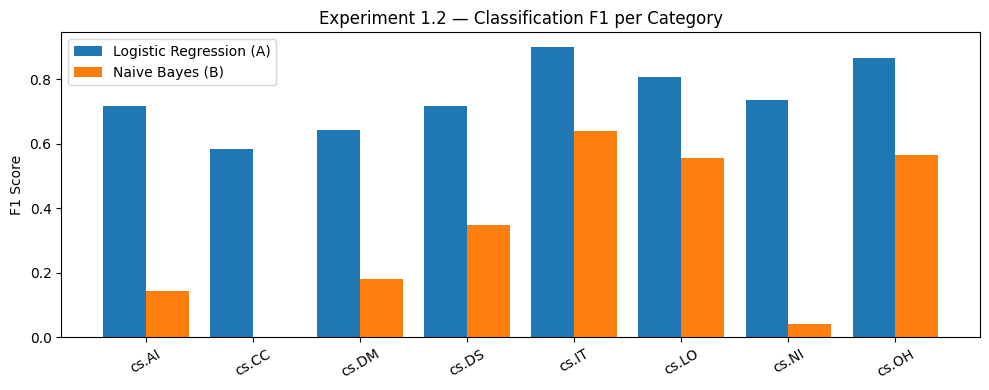

In [ ]:
# Visualise the F1 scores for each category for both classifiers
categories = sorted(common_categories)
f1_lr = [classification_report(y_test, pred_lr, output_dict=True, zero_division=0)[c]['f1-score'] for c in categories]
f1_nb = [classification_report(y_test, pred_nb, output_dict=True, zero_division=0)[c]['f1-score'] for c in categories]
x = np.arange(len(categories))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, f1_lr, 0.4, label='Logistic Regression (A)')
ax.bar(x + 0.2, f1_nb, 0.4, label='Naive Bayes (B)')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=30)
ax.set_ylabel('F1 Score')
ax.set_title('Experiment 1.2 — Classification F1 per Category')
ax.legend()
plt.tight_layout()
plt.show()

According to the image above, logistic Regression, the blue bar consistently outperforms Naive Bayes in orange across all 8 categories. The gap is most dramatic in cs.NI and cs.DM, where Naive Bayes scores near zero while Logistic Regression holds above 0.70. cs.IT is the only category where Naive Bayes comes close which reaches to 0.64 and aligning with its tendency to over-predict that class. cs.CC is the weakest for both models, suggesting it is the hardest category to distinguish. Overall the chart makes it clear that logistic Regression is the more reliable classifier than Naive Bayes, with more balanced performance across all categories rather than concentrating predictions on one dominant class.

### **Section 2.3 Summarisation - Ranking text extraction vs First-N sentence of abstract**

This section compares two summarisation approaches. Ranking-based text extraction selects the most important sentences from the content based on relevance, while the First-N sentence method uses the opening sentences of the abstract as a simple baseline summary. The comparison helps show whether extractive ranking produces more informative summaries than just taking the beginning of the abstract.

In [ ]:
# A function that summarise with TextRank 
# with sentences and TF-IDF vectors to rank sentences by importance and extract the top n sentences as the summary
# It uses cosine similarity to compute the similarity between sentences and ranks them based on their importance in the text, 
# returning the top n sentences as the summary
# filters out sentences that are too short (less than 20 characters) to ensure the summary is more informative
def textrank_summary(text, n=2):
    sentences = re.split(r'(?<=[.!?])\s+', text)
    sentences = []

    for s in re.split(r'(?<=[.!?])\s+', text):
        if len(s.strip()) > 20:
            sentences.append(s.strip())

    if len(sentences) <= n:
        return text
    vectorizer = TfidfVectorizer()
    sentence_vectors = vectorizer.fit_transform(sentences)
    similarity_matrix = cosine_similarity(sentence_vectors)
    scores = similarity_matrix.sum(axis=1)
    top_sentence_indices = scores.argsort()[-n:]
    top_sentence_indices = sorted(top_sentence_indices)
    summary = ' '.join(sentences[i] for i in top_sentence_indices)
    return summary

# A function that summarise with the first n sentences of the abstract
# filtering out sentences that are too short which is similar to the above 
def first_n_summary(text, n=2):
    all_sentences = re.split(r'(?<=[.!?])\s+', text)
    good_sentences = []

    for s in all_sentences:
        if len(s.strip()) > 20:
            good_sentences.append(s.strip())

    first_sentences = good_sentences[:n]
    return ' '.join(first_sentences)

# Print results 
abstract = SAMPLE['abstract']
summ_a = textrank_summary(abstract)
summ_b = first_n_summary(abstract)
print(f'Paper: {SAMPLE["title"]}')
print(f'\nTextRank Summary:')
print(summ_a)
print(f'\nFirst N Sentences Summary:')
print(summ_b)


Paper: Intelligent location of simultaneously active acoustic emission sources: Part I

TextRank Summary:
The location of acoustic emission on complicated aircraft frame structures is a difficult problem of non-destructive testing. The location accuracy achieved by the intelligent locator is comparable to that obtained by the conventional triangulation method, while the applicability of the intelligent locator is more general since analysis of sonic ray paths is avoided.

First N Sentences Summary:
The intelligent acoustic emission locator is described in Part I, while Part II discusses blind source separation, time delay estimation and location of two simultaneously active continuous acoustic emission sources. The location of acoustic emission on complicated aircraft frame structures is a difficult problem of non-destructive testing.


According to the summary of the paper on Intelligent location of simulataneous active acustic emission sources Part I, both summaries are generated with 2 techniques, TextRank and first N sentence. TextRank selects sentences based on how central they are to the overall text which picks up the core finding, that the intelligent locator matches triangulation accuracy while being more general. The result reads as a coherent standalone summary even without knowing the full paper.

First N Sentences simply takes the opening lines of the abstract with the first sentence as mostly structural ("Part I covers this, Part II covers that"), which is useful context but doesn't actually summarise what the paper found. The second sentence adds substance but the summary as a whole feels more like an introduction than a conclusion.

In this case TextRank produces the more informative summary as the most meaningful content wasn't at the start of the abstract but rather first N sentences is much simpler to implement and can work well when abstracts are written with the key finding upfront, which is common in well structured academic papers. TextRank's advantage is that it doesn't rely on sentence ordering, making it more robust across different writing styles.

### **Section 2.4 Recommendation - Dense Embedding Search v.s TF-IDF cosine simialrity**

This section compares two recommendation approaches: dense embedding search and TF-IDF cosine similarity. Dense embeddings capture semantic meaning between papers, allowing recommendations based on conceptual similarity rather than exact keyword overlap, while TF-IDF cosine similarity relies on shared terms and phrase frequency. Sentence embeddings also serve as the retrieval backbone for the RAG pipeline, making this comparison important for both recommendation quality and downstream retrieval performance.

#### **Section 2.4.1 Dense Embedding search** 

In [ ]:
# Initialize the embedding model
embedding_model_name = 'sentence-transformers/all-MiniLM-L6-v2'
embedding_model = SentenceTransformer(embedding_model_name)

# Encode the paper texts into dense embeddings using the sentence transformer model
embeddings = embedding_model.encode(
    papers['paper_text'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
)

# Build a nearest neighbors retriever using cosine similarity on the dense embeddings
retriever = NearestNeighbors(n_neighbors=8, metric='cosine')
retriever.fit(embeddings)
embeddings.shape

Batches: 100%|██████████| 125/125 [01:17<00:00,  1.61it/s]


(8000, 384)

In [ ]:
# A function to recommend papers based on a query using the dense embedding retriever
# it encodes the query into a dense embedding and retrieves the top k most similar papers based on cosine similarity,
# returning a DataFrame with the recommended papers and their similarity scores
def recommend_papers(query: str, top_k: int = 5) -> pd.DataFrame:
    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True,
    )
    distances, indices = retriever.kneighbors(
        query_embedding,
        n_neighbors=top_k,
    )
    results = papers.iloc[indices[0]].copy()
    results['similarity'] = 1 - distances[0]
    return results[
        [
            'id',
            'title',
            'authors',
            'categories',
            'keywords',
            'similarity',
            'abstract',
        ]
    ]


query = (
    'retrieval augmented generation for scientific literature review and '
    'citation recommendation'
)
recommendations = recommend_papers(query, top_k=5)
recommendations[['title', 'categories', 'keywords', 'similarity']]

,title,categories,keywords,similarity
129,Using Access Data for Paper Recommendations on...,cs.DL cs.IR,"[citation, access, org, recommendation, arxiv,...",0.589187
5147,Peer-review in the Internet age,physics.soc-ph cs.DL,"[review, peer, growing, scientific, internet, ...",0.574038
5717,An evaluation of Bradfordizing effects,cs.DL,"[articles, document, core, zones, zone, inform...",0.538805
4015,Universality of citation distributions: toward...,physics.soc-ph cond-mat.stat-mech cs.DL physic...,"[indicator, disciplines, citation, distributio...",0.526644
3085,"Citation Counting, Citation Ranking, and h-Ind...",cs.HC cs.IR,"[citation, web science, science, web, hci, res...",0.513336


#### **Section 2.4.2 TD-IDF Cosine simialrity**

In [ ]:
# A function to recommend papers based on a query using TF-IDF cosine similarity
# it transforms the query into a TF-IDF vector and computes cosine similarity with the TF-ID
# F matrix of the papers, returning the top k most similar papers based on cosine similarity,
# returning a DataFrame with the recommended papers and their similarity scores
def recommend_papers_tfidf_cosine_sim(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vec = tfidf.transform([preprocess(query)])
    scores = cosine_similarity(query_vec, tfidf_matrix).ravel()
    top_indices = scores.argsort()[-top_k:][::-1]
    results = papers.iloc[top_indices].copy()
    results['similarity'] = scores[top_indices]
    return results[
        [
            'id',
            'title',
            'authors',
            'categories',
            'keywords',
            'similarity',
            'abstract',
        ]
    ]

query = ('retrieval augmented generation for scientific literature review and citation recommendation')
recommendations_tfidf = recommend_papers_tfidf_cosine_sim(query, top_k=5)
recommendations_tfidf[['title', 'categories', 'keywords', 'similarity']]


,title,categories,keywords,similarity
129,Using Access Data for Paper Recommendations on...,cs.DL cs.IR,"[citation, access, org, recommendation, arxiv,...",0.282835
1403,Recommendation model based on opinion diffusion,physics.soc-ph cs.CY cs.IR physics.data-an,"[recommendation, diffusion, transition matrix,...",0.261527
5147,Peer-review in the Internet age,physics.soc-ph cs.DL,"[review, peer, growing, scientific, internet, ...",0.251136
4357,Scientific Paper Summarization Using Citation ...,cs.IR cs.CL,"[scientific, summarize, summary, citation, top...",0.249902
7605,Information Diffusion in Computer Science Cita...,cs.DL cs.CY,"[citation, papers, computer science, science, ...",0.221517


## **Section 3. Experiment 2: Comparison with Advanced Techniques**



### **Section 3.1 Summarisation - single shot vs instruction prompt vs few shot**

RAG combines the embedding retriever with a grounded context window so the LLM can recommend papers and discuss related work using retrieved evidence.

In [ ]:
# A function to call the Gemini API with a given prompt and return the generated content
def call_llm(prompt: str, model: str = 'gemini-2.5-flash') -> str:
    url = f'https://generativelanguage.googleapis.com/v1beta/models/{model}:generateContent'
    response = requests.post(
        url,
        params={'key': GEMINI_API_KEY},
        json={'contents': [{'parts': [{'text': prompt}]}]},
    )
    response.raise_for_status()
    return response.json()['candidates'][0]['content']['parts'][0]['text']

In [ ]:
# Function that builds a RAG context string from the recommended papers, 
# concatenating the title, authors, categories, keywords, and abstract of each paper into a single string with separators between papers
def build_rag_context(
    results: pd.DataFrame,
    max_chars_per_paper: int = 900,
) -> str:
    blocks = []
    for _, row in results.iterrows():
        abstract = row['abstract'][:max_chars_per_paper]
        blocks.append(
            f"Paper ID: {row['id']}\n"
            f"Title: {row['title']}\n"
            f"Authors: {row['authors']}\n"
            f"Categories: {row['categories']}\n"
            f"Keywords: {', '.join(row['keywords'])}\n"
            f"Abstract: {abstract}"
        )
    return '\n\n---\n\n'.join(blocks)


rag_context = build_rag_context(recommendations)
print(rag_context[:2500])

Paper ID: 0704.2963
Title: Using Access Data for Paper Recommendations on ArXiv.org
Authors: Stefan Pohl
Categories: cs.DL cs.IR
Keywords: citation, access, org, recommendation, arxiv, data, access data, data source
Abstract: This thesis investigates in the use of access log data as a source of information for identifying related scientific papers. This is done for arXiv.org, the authority for publication of e-prints in several fields of physics. Compared to citation information, access logs have the advantage of being immediately available, without manual or automatic extraction of the citation graph. Because of that, a main focus is on the question, how far user behavior can serve as a replacement for explicit meta-data, which potentially might be expensive or completely unavailable. Therefore, we compare access, content, and citation-based measures of relatedness on different recommendation tasks. As a final result, an online recommendation system has been built that can help scient

In [ ]:
TOPIC = 'retrieval augmented generation for scientific paper recommendation'

In [ ]:
# A single shot prompt that asks the LLM to summarise the main research direction about a given topic from the retrieved papers in 3-4 sentences, 
# providing the context of the retrieved papers for reference
def single_shot_prompt(topic: str, context: str) -> str:
    return (
        f'Summarise the main research direction about "{topic}" '
        f'from these papers in 3-4 sentences.\n\n{context}'
    )

# An instruction prompt that defines the role of the LLM as an expert academic research assistant specialising in a given topic
# it then instructs the LLM to summarise what the retrieved papers say about the topic, specifying the format of the summary and constraints on the content,
# providing the context of the retrieved papers for reference
def instruction_prompt(topic: str, context: str) -> str:
    return f"""[ROLE]
You are an expert academic research assistant specialising in {topic}.

[TASK]
Summarise what the retrieved papers say about: {topic}

[FORMAT]
## Summary
<3 sentences covering the main theme, methods used, and key findings>

[CONSTRAINTS]
- Only use information from the context.
- Be specific, not generic.

[CONTEXT]
{context}"""

# A few-shot prompt that provides examples of good paper summaries for different topics,
# then defines the role of the LLM as an expert academic research assistant and instructs it
# to summarise what the retrieved papers say about the topic
def few_shot_prompt(topic: str, context: str) -> str:
    return f"""You are an expert academic research assistant.

Here are examples of good paper summaries:

Example 1:
Topic: graph-based algorithms for sparse matrix decomposition
Summary: This research focuses on developing efficient algorithms for sparse graph decomposition. The methods combine combinatorial game theory with matrix factorization to certify sparsity. Key results show improved computational efficiency over prior approaches.

Example 2:
Topic: neural network compression using knowledge distillation
Summary: This area investigates reducing neural network size while preserving accuracy. Methods include teacher-student distillation and structured weight pruning. Results demonstrate up to 10x compression with minimal performance loss.

Now summarise the following papers about: {topic}

Papers:
{context}

## Summary
"""

# Call all three
resp_a = call_llm(single_shot_prompt(TOPIC, rag_context))
resp_b = call_llm(instruction_prompt(TOPIC, rag_context))
resp_c = call_llm(few_shot_prompt(TOPIC, rag_context))

# Print all 3 responses for comparison
print('\n=== Single-shot ===')
print(resp_a)
print('\n=== Instruction Prompt ===')
print(resp_b)
print('\n=== Few-shot Prompt ===')
print(resp_c)



=== Single-shot ===
Based on these papers from 2007-2008, the main research direction about scientific paper recommendation does **not** involve "retrieval augmented generation" (RAG). Instead, these studies focus on traditional bibliometric and information retrieval methods. They explore using access log data, citation networks, and established bibliometric techniques like Bradfordizing to identify related papers, evaluate scientific impact, and improve peer-review processes. The research primarily aims at developing automated systems for finding relevant literature and comparing the coverage and metrics of different scientific databases, predating the advent of generative AI and RAG architectures.

=== Instruction Prompt ===
## Summary
The retrieved papers do not discuss retrieval augmented generation for scientific paper recommendation. Instead, they focus on traditional methods, such as utilizing access log data for identifying related papers on arXiv.org and building online recom

According to the prompt respond with different prompting techniques, all three prompts reach the same conclusion where the retrieved papers predate RAG and focus on traditional bibliometric methods like citation networks and access logs, on the other hand, the quality of the output improves with prompt complexity. For more detail, single-shot gives a plain paragraph that gets the point across but lacks structure, instruction prompt is more concise and organised but feels dry, lastly, few-shot produces the most polished result, using italics and bold to highlight key terms and framing the limitation clearly. This further shows that even when the underlying information is the same, better prompt engineering leads to more readable and well structured outputs.

#### **Section 3.1.1 Fine-Tuning Setup Using LoRA**

LoRA is a parameter-efficient fine-tuning method. This setup shows how the recommender could adapt an instruction model to arXiv-style recommendation responses without updating all model weights. The training call is optional because full fine-tuning can be slow on CPU.

In [ ]:
# A function to build a small dataset of prompt-response pairs for LoRA fine-tuning, 
# using the recommended papers as examples
def build_lora_training_preview(sample_papers: pd.DataFrame) -> list[dict[str, str]]:
    examples = []
    for _, row in sample_papers.head(3).iterrows():
        prompt_text = (
            'Recommend this paper for a literature review and explain its fit.\n'
            f"Title: {row['title']}\n"
            f"Categories: {row['categories']}\n"
            f"Abstract: {row['abstract'][:700]}"
        )
        response_text = (
            f"Recommendation: {row['id']} - {row['title']}\n"
            f"Reason: This paper is relevant to {row['categories']} and matches the retrieved topic."
        )
        examples.append({'prompt': prompt_text, 'response': response_text})
    return examples


# Build a small dataset of prompt-response pairs for LoRA fine-tuning using the recommended papers as examples
lora_training_preview = build_lora_training_preview(recommendations)
lora_training_preview[0]


{'prompt': 'Recommend this paper for a literature review and explain its fit.\nTitle: Using Access Data for Paper Recommendations on ArXiv.org\nCategories: cs.DL cs.IR\nAbstract: This thesis investigates in the use of access log data as a source of information for identifying related scientific papers. This is done for arXiv.org, the authority for publication of e-prints in several fields of physics. Compared to citation information, access logs have the advantage of being immediately available, without manual or automatic extraction of the citation graph. Because of that, a main focus is on the question, how far user behavior can serve as a replacement for explicit meta-data, which potentially might be expensive or completely unavailable. Therefore, we compare access, content, and citation-based measures of relatedness on different recommendation tasks. As a final r',
 'response': 'Recommendation: 0704.2963 - Using Access Data for Paper Recommendations on ArXiv.org\nReason: This paper

In [ ]:
# A function to show the LoRA configuration for fine-tuning, including the task type, rank, alpha, dropout, and target modules
# it tries to import the necessary classes from the peft library and returns the configuration as a dictionary,
# if the library is not installed, it returns a dictionary with an error message and installation instructions
def show_lora_config() -> dict[str, object]:
    try:
        from peft import LoraConfig, TaskType

        config = LoraConfig(
            task_type=TaskType.SEQ_2_SEQ_LM,
            r=8,
            lora_alpha=16,
            lora_dropout=0.05,
            target_modules=['q', 'v'],
        )
        return config.to_dict()
    except Exception as exc:
        return {
            'status': 'LoRA config preview only',
            'reason': str(exc),
            'install': 'pip install peft',
        }


show_lora_config()


{'status': 'LoRA config preview only',
 'reason': "No module named 'peft'",
 'install': 'pip install peft'}

### **Section 3.2 Research gap identification - single-shot vs CoT vs ReAct**



This section compares three prompting strategies for research gap identification: single-shot, Chain-of-Thought (CoT), and ReAct. The prompt includes explicit instructions, structured output requirements, and grounding constraints to keep responses focused, consistent, and supported by the source material. This comparison helps evaluate which strategy produces the clearest and most reliable gap analysis.

In [ ]:
def gap_single_shot(topic: str, context: str) -> str:
    return f'What are the research gaps about "{topic}" based on these papers?\n\n{context}'


def gap_cot(topic: str, context: str) -> str:
    return f"""You are a research analyst. Think step by step before writing your answer.

<scratchpad>
Step 1 – Read each paper and note its core contribution in one sentence.
Step 2 – Group papers by shared theme or methodology.
Step 3 – Identify what topics or methods none of the papers cover.
Step 4 – Assess the overall maturity of the field.
</scratchpad>

After the scratchpad, write **Final Answer:** with 2 specific research gaps about: {topic}

Papers:
{context}"""


def gap_react(topic: str, context: str) -> str:
    return f"""You are a research analyst. Find research gaps by reasoning and acting in alternating steps.

Available actions:
  read(paper_id)        – read a paper's contribution and methodology
  compare(id1, id2)     – identify what one paper covers that the other does not
  check_coverage(topic) – check if any paper in the context covers this topic
  conclude()            – state the final research gaps found

Rules:
- Use read() on at least 3 papers before concluding.
- Use check_coverage() to verify a gap is genuinely missing.
- Use compare() at least once to contrast approaches.
- Observations must only use facts from the context below.
- Each Thought must be one sentence.

Format every step as:
  Thought: <what you need to check next>
  Action: <one action from the list>
  Observation: <what you find>

End with:
  Thought: I have identified genuine gaps.
  Action: conclude()
  Research Gaps:
    Gap 1: <specific missing topic or method>
    Gap 2: <specific missing topic or method>
  Why these are gaps: <one sentence>

User question: What are the research gaps in {topic}?

Context:
{context}

Begin:"""


# Call all three
resp_gap_a = call_llm(gap_single_shot(TOPIC, rag_context))
resp_gap_b = call_llm(gap_cot(TOPIC, rag_context))
resp_gap_c = call_llm(gap_react(TOPIC, rag_context))

print('\n=== Single-shot Gap Finding ===')
print(resp_gap_a)
print('\n=== Chain-of-Thought Gap Finding ===')
print(resp_gap_b)
print('\n=== ReAct Gap Finding ===')
print(resp_gap_c)



=== Single-shot Gap Finding ===
Based on the provided papers, the research gaps concerning "retrieval augmented generation (RAG) for scientific paper recommendation" are significant and fundamental, primarily because these papers predate the widespread adoption of large language models (LLMs) and the RAG paradigm itself.

Here are the key research gaps identified:

1.  **Absence of Large Language Models (LLMs) and Generative Components:**
    *   All papers focus on traditional information retrieval (IR), bibliometric methods, or classic recommender system approaches. They utilize data like access logs, citation networks, content keywords, and bibliometric indicators (Bradfordizing, h-index).
    *   There is **no mention or integration of LLMs** for any part of the recommendation process. The "generation" component of RAG, which involves synthesizing retrieved information into coherent natural language, is entirely missing from these works.

2.  **Lack of Natural Language Explanation

### **Section 3.3 Paper recommendation - LLM without context vs RAG + instruction prompt vs RAG + ReAct**

This section compares three paper recommendation strategies: an LLM without external context, RAG with a structured instruction prompt, and RAG with ReAct. The comparison evaluates how added retrieval and reasoning steps affect recommendation relevance, justification quality, and grounding in the source material.

In [ ]:
# A function to recommend papers based on a query using an LLM without context,
# it simply asks the LLM to recommend papers relevant to the topic without providing any retrieved context, 
# instructing it to provide paper titles and reasons without making up paper IDs
def no_context_prompt(topic: str) -> str:
    return (
        f'Recommend 3 papers relevant to: "{topic}". '
        f'Provide paper titles and reasons. Do not make up paper IDs.'
    )

# A function to recommend papers based on a query using an LLM with a RAG instruction prompt,
# it defines the role of the LLM as an academic research assistant and instructs it to summarise the main research direction, recommend relevant papers with explanations,
# identify research gaps, and suggest future research directions.
def make_rag_prompt(topic: str, context: str) -> str:
    return f"""
You are an academic research assistant.
Use only the retrieved paper context below.

Task:
1. Summarize the main research direction in 4 bullet points.
2. Recommend the 3 most relevant papers and explain why.
3. Identify 2 likely research gaps.
4. Suggest one future research question.

Grounding rules:
- Cite paper IDs from the context.
- If the context is insufficient, say what is missing.
- Do not invent papers, authors, or results.

User question: {topic}

Retrieved context:
{context}

Answer:
""".strip()

# A function to recommend papers based on a query using an LLM with a RAG ReAct prompt,
# it defines the role of the LLM as a research assistant and instructs it to reason
# and act in alternating steps, simulating the entire process to generate both the actions and the observations based on the context of the retrieved papers,
# providing a list of available actions (search, inspect, compare, conclude) and rules for how to use them, and specifying the format for the thought process, actions, and observations, with
# the user question and retrieved context provided for reference at the end of the prompt
def rag_react_prompt(topic: str, context: str) -> str:
    return f"""You are a research assistant. Reason and act in alternating steps.
You must simulate the ENTIRE loop yourself, by generating both the actions AND the observations based on the context below. Do not stop after an action.

Available actions:
  search(keyword)    – find papers in context matching a keyword
  inspect(paper_id)  – read a paper's contribution
  compare(id1, id2)  – compare two papers
  conclude(paper_id) – declare best paper with 3-sentence justification

Rules:
- Immediately follow every Action with an Observation from the context.
- Use search(), inspect(), compare() before conclude().
- Observations must come from the context only.

Format:
  Thought: ...
  Action: search(keyword)
  Observation: [find matching papers from context and describe them]
  Thought: ...
  Action: inspect(paper_id)
  Observation: [read that paper from context and describe its contribution]
  Thought: I have enough information.
  Action: conclude(paper_id)
  Final Answer: [3-sentence justification]

User need: {topic}

Context:
{context}

Begin:"""


# Call all three
resp_a = call_llm(no_context_prompt(TOPIC))
resp_b = call_llm(make_rag_prompt(TOPIC, rag_context))
resp_c = call_llm(rag_react_prompt(TOPIC, rag_context))

# Print all 3 responses for comparison
print('\n=== LLM without Context ===')
print(resp_a)
print('\n=== RAG + Instruction Prompt ===')
print(resp_b)
print('\n=== RAG + ReAct ===')
print(resp_c)



=== LLM without Context ===
Here are three highly relevant papers covering different significant eras and methods within "deep learning for text classification":

1.  **Paper Title:** "A Convolutional Neural Network for Text Classification"
    *   **Reason:** This seminal paper by Yoon Kim (2014) is often cited as one of the first major demonstrations of how Convolutional Neural Networks (CNNs), traditionally used in computer vision, could be effectively adapted for text classification. It showed that even a relatively simple CNN architecture, when combined with pre-trained word embeddings (like Word2Vec), could achieve state-of-the-art performance on various text classification benchmarks, significantly impacting the field and popularizing CNNs for NLP tasks.

2.  **Paper Title:** "Attention Is All You Need"
    *   **Reason:** While not *directly* a text classification paper, this groundbreaking work by Vaswani et al. (2017) introduced the Transformer architecture. The Transformer,

According to the respond on the above, the three approaches handle the same mismatch differently with the query asks about deep learning but the retrieved papers are about bibliometrics. LLM without context confidently recommends CNN, Transformer, and BERT papers from its training knowledge, which sound relevant but are completely fabricated relative to the actual dataset which indicate a hallucination risk in paper recommendation. RAG + Instruction Prompt acknowledges the mismatch honestly and redirects its analysis to what the context actually contains. RAG + ReAct is the most transparent, showing its reasoning step by step before concluding it cannot answer which also highlights RAG's key advantage which is stays grounded and avoids making up results.

## **Section 4. Experiment 3: Basic vs advanced technique**

This experiment compares baseline methods with more advanced techniques across the pipeline. The goal is to measure whether stronger retrieval, prompting, and representation methods lead to better performance and more reliable outputs than simpler approaches.

In [ ]:
# Define the topic for paper recommendations
TOPIC = 'deep learning methods for text classification'
retrieved      = recommend_papers(TOPIC, top_k=5)
rag_ctx        = build_rag_context(retrieved)
sample_abstract = retrieved.iloc[0]['abstract']

### **Section 4.1 Research Gap Identification - Classification + Keyword Comparison vs CoT**

This section compares a basic research gap identification approach with a Chain-of-Thought (CoT) prompting method. The basic approach infers gaps by classifying the paper’s domain and comparing its keywords with broader domain-level keywords, while CoT uses structured step-by-step reasoning over retrieved context to identify missing topics or methods. The comparison evaluates whether guided reasoning produces more meaningful gap analysis than simple keyword-based matching.

In [ ]:
# Print the result of the CoT prompt with the keyword fitted into the prompt 
# See whether this would improve the performance and the repsond of the LLM 
# In paper recommendation 
sample_domain = classifier.predict([SAMPLE['clean_text']])[0]
domain_papers = papers[papers['primary_category'] == sample_domain]

domain_tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,1), min_df=2)
domain_matrix = domain_tfidf.fit_transform(domain_papers['clean_text'])
domain_scores = np.asarray(domain_matrix.mean(axis=0)).ravel()
domain_terms  = np.array(domain_tfidf.get_feature_names_out())
top_domain_kw = set(domain_terms[domain_scores.argsort()[-30:][::-1]])
paper_kw      = set(top_keywords(SAMPLE_IDX, k=20))
basic_gaps    = top_domain_kw - paper_kw

print(f'Paper domain: {sample_domain}')
print(f'Paper keywords    : {sorted(paper_kw)[:10]}')
print(f'Domain keywords   : {sorted(top_domain_kw)[:10]}')
print(f'Basic gaps (missing from paper): {sorted(basic_gaps)[:10]}')

advanced_gaps = call_llm(gap_cot(TOPIC, rag_context))

print('\n=== CoT LLM Gaps ===')
print(advanced_gaps)


Paper domain: cs.AI
Paper keywords    : ['accuracy', 'acoustic', 'active', 'attenuation', 'destructive', 'emission', 'frame', 'intelligent', 'location', 'locator']
Domain keywords   : ['algorithm', 'analysis', 'approach', 'based', 'can', 'constraint', 'constraints', 'data', 'decision', 'have']
Basic gaps (missing from paper): ['algorithm', 'analysis', 'approach', 'based', 'can', 'constraint', 'constraints', 'data', 'decision', 'have']

=== CoT LLM Gaps ===
The provided papers primarily focus on traditional bibliometric methods, citation analysis, access log data, and information retrieval techniques within scholarly information systems. They date from 2007-2008, predating the widespread adoption and advancement of deep learning, particularly for natural language processing (NLP) and text classification.

Based on an analysis of these papers, here are two specific research gaps concerning "deep learning methods for text classification":

1.  **Absence of Deep Learning Architectures for 

According to the CoT prompt with keyword input, the basic keyword comparison identifies gaps by finding domain level terms missing from the paper, but the results are relatively poor. Words like based, can, and have appear as gaps simply because they are common across cs.AI papers, not because they represent meaningful research directions, thus the method has no understanding of context which is bad and not what is wanted throughout. 

CoT prompting produces far more useful gaps, identifying the absence of deep learning architectures and transfer learning as genuine missing areas. It reasons about why these gaps exist and connects them to the paper's topic. This clearly shows the limitation of keyword subtraction as a gap finding method compared to LLM reasoning.

### **Section 4.2 Paper Recommendation**

This section compares a basic TF-IDF similarity baseline with an advanced RAG + ReAct recommendation approach. The baseline recommends papers based on keyword overlap and cosine similarity, while the advanced method uses retrieved context and step-by-step reasoning to generate more grounded and context-aware recommendations. The comparison shows whether retrieval-augmented reasoning improves recommendation relevance and explanation quality.

In [ ]:
# Compare basic keyword matching recommendation with RAG + ReAct recommendation for the same query
query_vec  = tfidf.transform([preprocess(query)])
scores     = cosine_similarity(query_vec, tfidf_matrix).ravel()
top_idx    = scores.argsort()[-5:][::-1]
basic_recommendations = papers.iloc[top_idx][['id','title','primary_category']].copy()
basic_recommendations['tfidf_score'] = scores[top_idx]

print('=== TF-IDF Keyword Match ===')
print(basic_recommendations.to_string(index=False))

advanced_recommendations = call_llm(rag_react_prompt(TOPIC, rag_ctx))
print('\n=== RAG + ReAct Answer ===')
print(advanced_recommendations)



=== TF-IDF Keyword Match ===
       id                                                          title primary_category  tfidf_score
0704.2963       Using Access Data for Paper Recommendations on ArXiv.org            cs.DL     0.282835
0710.2228                Recommendation model based on opinion diffusion   physics.soc-ph     0.261527
0810.0486                                Peer-review in the Internet age   physics.soc-ph     0.251136
0807.1560 Scientific Paper Summarization Using Citation Summary Networks            cs.IR     0.249902
0905.2636    Information Diffusion in Computer Science Citation Networks            cs.DL     0.221517

=== RAG + ReAct Answer ===
Thought: The user is looking for deep learning methods for text classification. I will start by searching for keywords like "deep learning," "neural network," and "text classification" to identify relevant papers.
Action: search(deep learning text classification)
Observation: No direct matches for "deep learning text classi

According to the above, the TF-IDF keyword matching returns papers about citation networks and recommendation systems which none presented are relevant to deep learning for text classification. It mainly based on matches on surface-level word overlap, so it retrieves topically unrelated papers that happen to share common terms.

RAG + ReAct takes a more intelligent approach, actively searching, inspecting, and comparing papers before concluding. It correctly identifies that no paper in the corpus directly addresses the query, and settles on the closest available match with transparent reasoning and caveats, further demonstrates that RAG + ReAct's key strength is about relevance rather than just measuring term frequency, and is honest when the context falls short.

### **Section 4.3 Summarisation**

This section compares a basic extractive summarisation method with an advanced LLM-based summarisation approach. The basic method uses TextRank to select representative sentences from the retrieved abstracts, while the advanced method uses instruction prompting over retrieved context to produce a more coherent and topic-focused summary. The comparison evaluates whether the advanced approach generates clearer and more informative summaries than the baseline.

In [ ]:
# Compare basic TextRank summarisation with instruction prompting summarisation for the same retrieved papers
combined_text = ' '.join(retrieved['abstract'].tolist())
basic_summary = textrank_summary(combined_text, n=3)
advanced_summary = call_llm(instruction_prompt(TOPIC, rag_context))

# Print both summaries for comparison
print('=== TextRank ===')
print(basic_summary)
print('\n=== Instruction prompting ===')
print(advanced_summary)

=== TextRank ===
In this paper, we present a scalable non-linear feature mapping method based on a deep neural network pretrained with restricted boltzmann machines for improving kNN classification in a large-margin framework, which we call DNet-kNN. The method, its application is presented in the paper, is based on statistic regularities connected with the presence of definite lexemes in the texts. We compare the performance of a recurrent neural network with the best results published so far on phoneme recognition in the TIMIT database.

=== Instruction prompting ===
## Summary
The provided papers do not discuss deep learning methods for text classification. Instead, they focus on topics such as using access log data and citation networks for paper recommendation systems, evaluating bibliometric methods like Bradfordizing for information retrieval, and comparing citation databases for measuring scientific impact.


### **Section 4.4. Combine basic with advanced approach**

In [ ]:
# Function to create an instruction prompt for summarisation, 
# defining the role of the LLM as an expert academic research assistant specialising in a given topic,
# instructing it to summarise what the retrieved papers say about the topic in 3 sentences covering the main theme, methods used, and key findings,
# and providing constraints to only use information from the context and to be specific, with the context of the retrieved papers provided for reference
def instruction_prompt(topic: str, enriched_context: str) -> str:
    return f"""[ROLE]
You are an expert academic research assistant specialising in {topic}.

[TASK]
Summarise what the retrieved papers say about: {topic}
Pay attention to the Query domain and Query keywords at the top of the context
as they indicate the specific focus area.

[FORMAT]
## Summary
<3 sentences covering the main theme, methods used, and key findings>

[CONSTRAINTS]
- Only use information from the context.
- Be specific, not generic.
- Reference the domain and keywords where relevant.

[CONTEXT]
{enriched_context}"""


In [ ]:
# A function to create a chain-of-thought prompt for research gap identification,
# defining the role of the LLM as a research analyst and instructing it to think step
# by step before writing the answer, providing a scratchpad with specific steps to follow for identifying research gaps based on the retrieved papers, 
# and then asking for a final answer with 2 specific research gaps about the topic, with the context of the retrieved papers provided for reference
def make_gap_cot(topic: str, enriched_context: str) -> str:
    return f"""You are a research analyst. Think step by step before writing your answer.

<scratchpad>
Step 1 – Note the query domain and keywords at the top of the context.
Step 2 – Read each paper and note its core contribution in one sentence.
Step 3 – Check which query keywords are NOT covered by any paper.
Step 4 – Identify what topics in this domain none of the papers address.
</scratchpad>

After the scratchpad, write **Final Answer:** with 2 specific research gaps about: {topic}
Focus on gaps related to the domain and keywords provided.

Papers:
{enriched_context}"""


In [ ]:
def make_rag_prompt(topic: str, enriched_context: str) -> str:
    return f"""You are an academic research assistant.
Use only the retrieved paper context below.

Task:
1. Summarise the main research direction in 4 bullet points.
2. Recommend the 3 most relevant papers and explain why.
3. Identify 2 likely research gaps related to the query keywords.
4. Suggest one future research question in the query domain.

Grounding rules:
- Cite paper IDs from the context.
- Use the Query domain and Query keywords to focus your answer.
- Do not invent papers, authors, or results.

User question: {topic}

Retrieved context:
{enriched_context}

Answer:""".strip()


In [ ]:
# A function to extract the top k keywords from a given text using the fitted TF-IDF vectorizer,
# it transforms the input text into a TF-IDF vector, retrieves the corresponding terms, and returns the top k keywords based on their TF-IDF scores, or an empty list if no keywords are found
# This is used to enrich the context for the LLM by providing it with the most relevant keywords from the query text, which can help guide its understanding and response generation based on the retrieved papers
# It ensures that the LLM has a clearer focus on the specific aspects of the topic that are most relevant, potentially improving the quality and relevance of its output
def top_keywords_from_text(text: str, k: int = 8) -> list:
    vec = tfidf.transform([preprocess(text)])
    row = vec.toarray().ravel()
    if row.sum() == 0:
        return []
    return terms[row.argsort()[-k:][::-1]].tolist()

query_keywords = top_keywords_from_text(TOPIC)
print(f'TF-IDF Keywords from query: {query_keywords}')


query_domain = classifier.predict([preprocess(TOPIC)])[0]
print(f'Classified domain: {query_domain}')

enriched_context = (
    f"Query domain: {query_domain}\n"
    f"Query keywords: {', '.join(query_keywords)}\n\n"
    f"{rag_context}"
)

print('\n=== Enriched Context Preview ===')
print(enriched_context[:500])

TF-IDF Keywords from query: ['deep', 'text', 'classification', 'learning', 'methods', 'zones', 'fiber', 'figure']
Classified domain: cs.AI

=== Enriched Context Preview ===
Query domain: cs.AI
Query keywords: deep, text, classification, learning, methods, zones, fiber, figure

Paper ID: 0704.2963
Title: Using Access Data for Paper Recommendations on ArXiv.org
Authors: Stefan Pohl
Categories: cs.DL cs.IR
Keywords: citation, access, org, recommendation, arxiv, data, access data, data source
Abstract: This thesis investigates in the use of access log data as a source of information for identifying related scientific papers. This is done for arXiv.org, the authority fo


In [ ]:
# Print all the results 
print('\n=== Summary (Instruction + Keywords + Domain) ===')
print(call_llm(instruction_prompt(TOPIC, enriched_context)))

print('\n=== Research Gaps (CoT + Keywords + Domain) ===')
print(call_llm(make_gap_cot(TOPIC, enriched_context)))

print('\n=== Recommendation (RAG + Instruction + Keywords + Domain) ===')
print(call_llm(make_rag_prompt(TOPIC, enriched_context)))


=== Summary (Instruction + Keywords + Domain) ===
## Summary
The retrieved papers do not discuss deep learning methods for text classification. Instead, they primarily focus on bibliometric and information retrieval methods for tasks like paper recommendations and citation analysis within the `cs.AI` domain. For instance, one paper (0812.0262) evaluates "Bradfordizing" as a method for information retrieval, applying it to generate core document sets and reorder results by identifying subject-specific "zones." Other papers explore using access data for paper recommendations (0704.2963), propose automated models for peer review based on citation network properties (0810.0486), and analyze citation distributions or compare citation databases (0806.0974, 0803.1716).

=== Research Gaps (CoT + Keywords + Domain) ===
**Query domain:** cs.AI
**Query keywords:** deep, text, classification, learning, methods, zones, fiber, figure

**Scratchpad:**

*   **Step 1 – Note the query domain and keywor

According to the above, adding domain and keyword context to the prompts noticeably improves all prompt output where the summary correctly identifies the cs.AI domain and cites specific paper IDs rather than speaking vaguely and having the CoT gap analysis with a strongest result such that the systematically checks each query keyword against the retrieved papers and clearly explains why terms like deep and learning are absent, producing two well reasoned gaps. In addition, the RAG recommendation honestly acknowledges the mismatch but still extracts the most tangentially relevant papers with justification. In conclusion, the overall enriching the context with domain and keywords gives the LLM a sharper focus and more grounded, specific outputs.